Dataset Shape : (284858, 16)
   Gender  Country  Occupation  self_employed  family_history  treatment  \
0       0       34           1              0               1          1   
1       0       34           1              0               1          1   
2       0       25           1              0               0          1   
3       0        0           1              0               1          1   
4       0       34           1              0               0          0   

   Days_Indoors  Growing_Stress  Changes_Habits  Mental_Health_History  \
0             0               2               1                      2   
1             0               2               1                      2   
2             0               2               1                      2   
3             0               2               1                      2   
4             0               2               1                      2   

   Mood_Swings  Coping_Struggles  Work_Interest  Social_Weakness  \
0

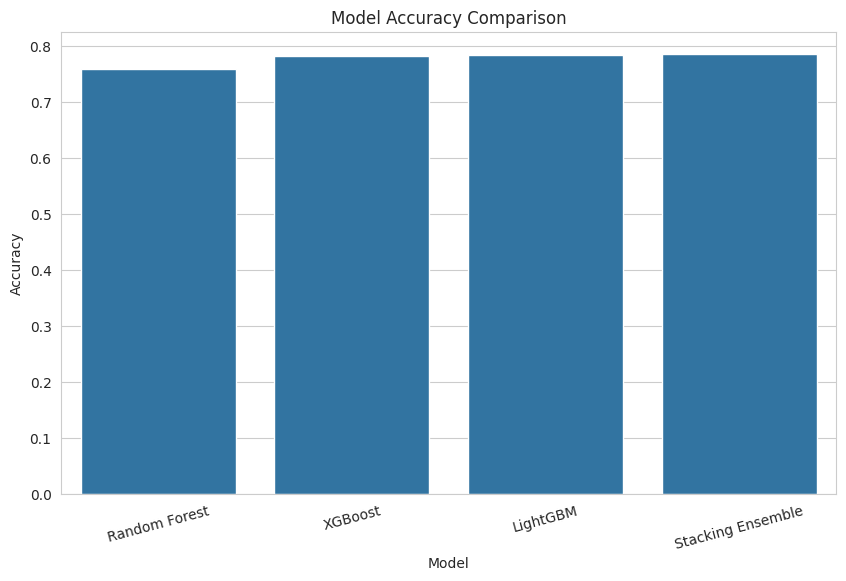

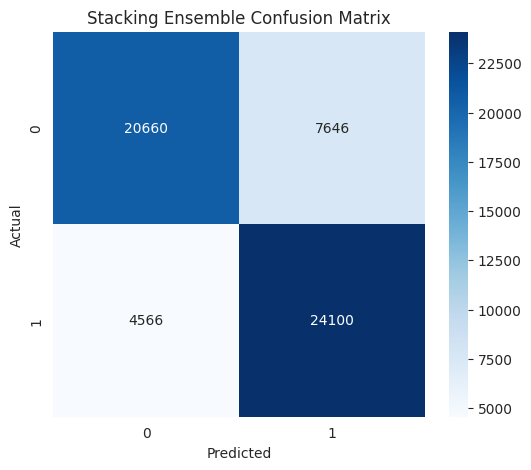

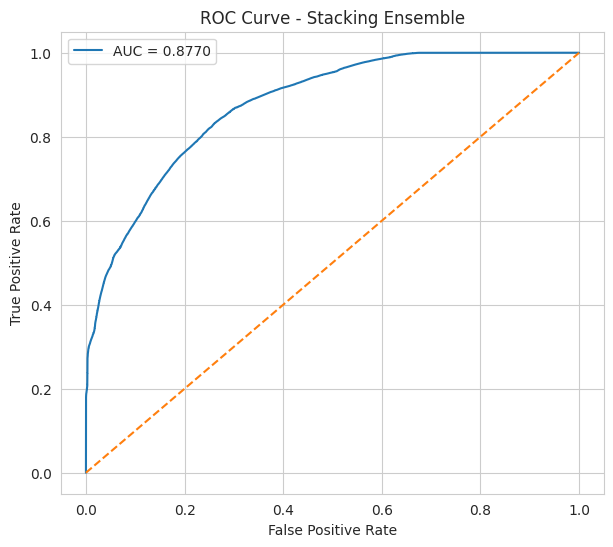

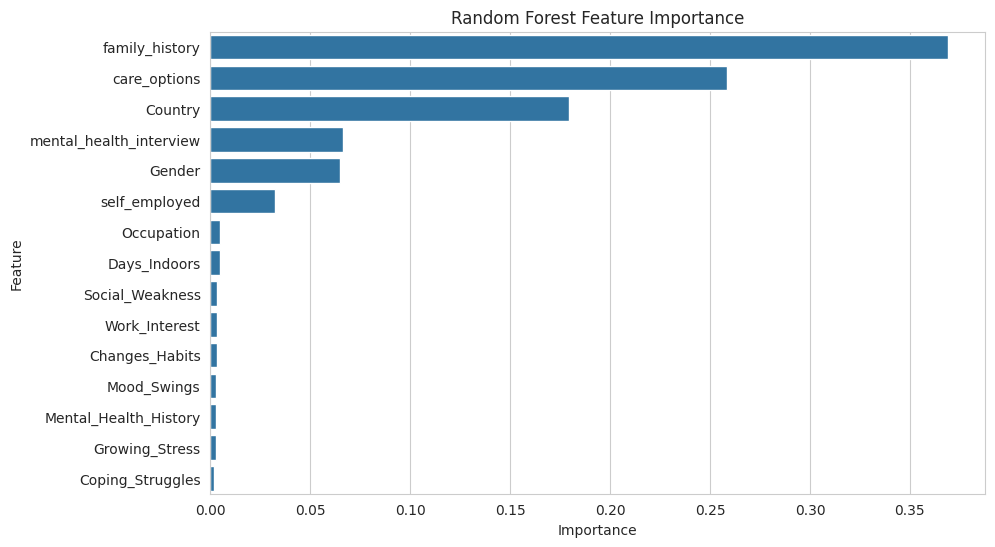

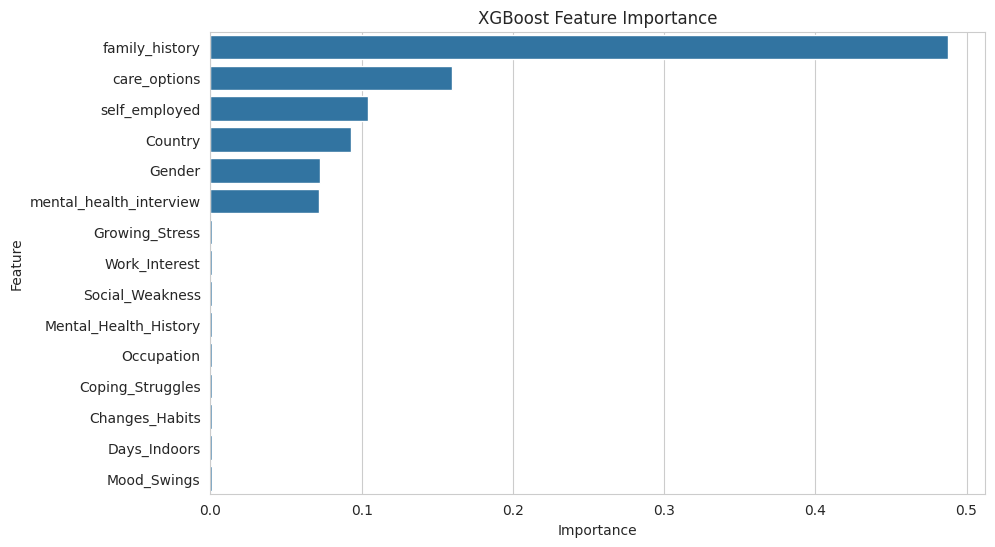

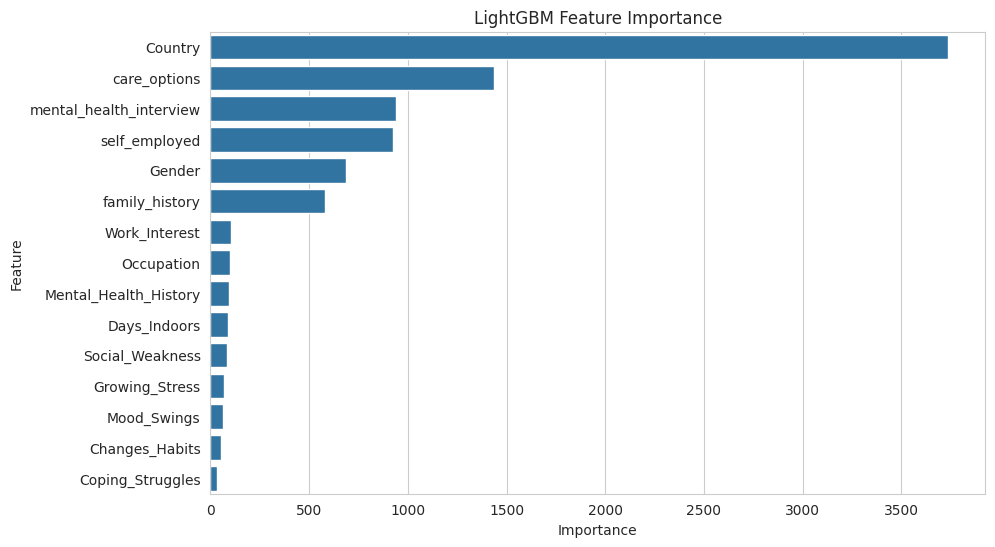


Performing Stratified K-Fold Cross Validation...
[LightGBM] [Info] Number of positive: 114664, number of negative: 113222
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024591 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 77
[LightGBM] [Info] Number of data points in the train set: 227886, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503164 -> initscore=0.012656
[LightGBM] [Info] Start training from score 0.012656
[LightGBM] [Info] Number of positive: 91731, number of negative: 90577
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019742 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 77
[LightGBM] [Info] Number of data points in the train set: 182308

In [1]:
# ============================================================
# MENTAL HEALTH PREDICTION SYSTEM - STACKING ENSEMBLE PIPELINE
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

# Models
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    r2_score
)

# Save Model
import joblib

# Create folders
import os
os.makedirs("plots", exist_ok=True)
os.makedirs("saved_models", exist_ok=True)

# Style
sns.set_style("whitegrid")

# ============================================================
# 2. LOAD DATASET
# ============================================================

# Upload encoded dataset CSV in Colab
df = pd.read_csv("/content/encoded_mental_health_dataset.csv")

print("Dataset Shape :", df.shape)
print(df.head())

# ============================================================
# 3. SEPARATE FEATURES AND TARGET
# ============================================================

target_column = "treatment"

X = df.drop(columns=[target_column])
y = df[target_column]

print("\nFeature Shape :", X.shape)
print("Target Shape :", y.shape)

# ============================================================
# 4. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

# ============================================================
# 5. DEFINE BASE MODELS
# ============================================================

# ---------------- Random Forest ----------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# ---------------- XGBoost ----------------

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# ---------------- LightGBM ----------------

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# ============================================================
# 6. TRAIN INDIVIDUAL MODELS
# ============================================================

print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

print("Training LightGBM...")
lgbm_model.fit(X_train, y_train)

# ============================================================
# 7. BUILD STACKING CLASSIFIER
# ============================================================

estimators = [
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('lgbm', lgbm_model)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    passthrough=False
)

# ============================================================
# 8. TRAIN STACKING MODEL
# ============================================================

print("\nTraining Stacking Ensemble...")
stack_model.fit(X_train, y_train)

# ============================================================
# 9. PREDICTIONS
# ============================================================

rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
lgbm_pred = lgbm_model.predict(X_test)
stack_pred = stack_model.predict(X_test)

# Probabilities
stack_prob = stack_model.predict_proba(X_test)[:, 1]

# ============================================================
# 10. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model_name, y_true, y_pred, y_prob=None):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    if y_prob is not None:
        roc_auc = roc_auc_score(y_true, y_prob)
    else:
        roc_auc = np.nan

    # R² Score (not ideal for classification)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"{model_name} PERFORMANCE")
    print(f"{'='*50}")

    print("Accuracy      :", round(accuracy, 4))
    print("Precision     :", round(precision, 4))
    print("Recall        :", round(recall, 4))
    print("F1 Score      :", round(f1, 4))
    print("ROC-AUC Score :", round(roc_auc, 4))
    print("R² Score      :", round(r2, 4))

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "R2 Score": r2
    }

# ============================================================
# 11. EVALUATE ALL MODELS
# ============================================================

results = []

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_model.predict_proba(X_test)[:,1]
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred,
        xgb_model.predict_proba(X_test)[:,1]
    )
)

results.append(
    evaluate_model(
        "LightGBM",
        y_test,
        lgbm_pred,
        lgbm_model.predict_proba(X_test)[:,1]
    )
)

results.append(
    evaluate_model(
        "Stacking Ensemble",
        y_test,
        stack_pred,
        stack_prob
    )
)

# ============================================================
# 12. COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\nMODEL COMPARISON TABLE\n")
print(results_df)

# ============================================================
# 13. VISUALIZE MODEL COMPARISON
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)

plt.savefig("plots/model_comparison.png")
plt.show()

# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, stack_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Stacking Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("plots/confusion_matrix.png")
plt.show()

# ============================================================
# 15. ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, stack_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Stacking Ensemble")
plt.legend()

plt.savefig("plots/roc_curve.png")
plt.show()

# ============================================================
# 16. FEATURE IMPORTANCE FUNCTION
# ============================================================

def plot_feature_importance(model, model_name):

    importance = model.feature_importances_

    feature_imp = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    })

    feature_imp = feature_imp.sort_values(
        by='Importance',
        ascending=False
    ).head(15)

    plt.figure(figsize=(10,6))

    sns.barplot(
        x='Importance',
        y='Feature',
        data=feature_imp
    )

    plt.title(f"{model_name} Feature Importance")

    plt.savefig(
        f"plots/{model_name.lower().replace(' ','_')}_feature_importance.png"
    )

    plt.show()

# Plot Feature Importances
plot_feature_importance(rf_model, "Random Forest")
plot_feature_importance(xgb_model, "XGBoost")
plot_feature_importance(lgbm_model, "LightGBM")

# ============================================================
# 17. STRATIFIED K-FOLD CROSS VALIDATION
# ============================================================

print("\nPerforming Stratified K-Fold Cross Validation...")

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    stack_model,
    X,
    y,
    cv=skf,
    scoring='accuracy'
)

print("\nCross Validation Scores :", cv_scores)
print("Average CV Accuracy     :", cv_scores.mean())

# ============================================================
# 18. HYPERPARAMETER TUNING
# ============================================================

print("\nPerforming Hyperparameter Tuning...")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters :", grid_search.best_params_)
print("Best Score      :", grid_search.best_score_)

# ============================================================
# 19. OVERFITTING DETECTION
# ============================================================

train_acc = accuracy_score(
    y_train,
    stack_model.predict(X_train)
)

test_acc = accuracy_score(
    y_test,
    stack_pred
)

print("\nOVERFITTING ANALYSIS")
print("="*40)

print("Training Accuracy :", round(train_acc, 4))
print("Testing Accuracy  :", round(test_acc, 4))

if train_acc - test_acc > 0.05:
    print("\nPossible Overfitting Detected")
else:
    print("\nModel Generalization Looks Good")

# ============================================================
# 20. SAVE MODEL
# ============================================================

joblib.dump(
    stack_model,
    "saved_models/stacking_model.pkl"
)

print("\nModel Saved Successfully!")

# ============================================================
# END OF PIPELINE
# ============================================================